In [1]:

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

df_raw = pd.read_csv(r'results\uploads\diabetes.csv')
df_clean = None
df_features = None
DATASET_COLUMNS = list(df_raw.columns)
NUMERIC_COLUMNS = df_raw.select_dtypes(include=[np.number]).columns.tolist()
CATEGORICAL_COLUMNS = df_raw.select_dtypes(include=['object', 'category']).columns.tolist()
DATASET_SHAPE = df_raw.shape
ORIGINAL_NUMERIC_COLUMNS = NUMERIC_COLUMNS.copy()
ORIGINAL_CATEGORICAL_COLUMNS = CATEGORICAL_COLUMNS.copy()
print(f"Loaded {DATASET_SHAPE[0]} rows x {DATASET_SHAPE[1]} columns")


Loaded 1150 rows x 20 columns


In [2]:

import json as _json

# Compute correlations for numeric columns
_corr_matrix = df_raw[NUMERIC_COLUMNS].corr() if len(NUMERIC_COLUMNS) > 1 else None
_top_correlations = []
if _corr_matrix is not None:
    for i, col1 in enumerate(NUMERIC_COLUMNS):
        for col2 in NUMERIC_COLUMNS[i+1:]:
            corr_val = abs(_corr_matrix.loc[col1, col2])
            if corr_val > 0.5:
                _top_correlations.append((col1, col2, round(corr_val, 3)))
    _top_correlations.sort(key=lambda x: x[2], reverse=True)
    _top_correlations = _top_correlations[:10]  # Top 10

# Compute skewness for numeric columns
_skewness = {}
for col in NUMERIC_COLUMNS:
    try:
        _skewness[col] = round(float(df_raw[col].skew()), 3)
    except:
        pass
_highly_skewed = [col for col, skew in _skewness.items() if abs(skew) > 1]

# Identify binary columns
_binary_columns = [col for col in df_raw.columns if df_raw[col].nunique() == 2]

# Identify potential target columns (binary or low cardinality categorical)
_potential_targets = [col for col in df_raw.columns if 2 <= df_raw[col].nunique() <= 10]

# Check class balance for potential targets (for class_imbalance skip decision)
_class_balance = {}
for col in _binary_columns + [c for c in _potential_targets if c not in _binary_columns]:
    try:
        counts = df_raw[col].value_counts(normalize=True)
        if len(counts) >= 2:
            majority_pct = float(counts.iloc[0] * 100)
            minority_pct = float(counts.iloc[1] * 100)
            _class_balance[col] = {
                'majority_pct': round(majority_pct, 1),
                'minority_pct': round(minority_pct, 1),
                'is_imbalanced': bool(majority_pct > 70)
            }
    except:
        pass

_profile = {
    'shape': list(df_raw.shape),
    'columns': list(df_raw.columns),
    'dtypes': df_raw.dtypes.astype(str).to_dict(),
    'numeric_columns': NUMERIC_COLUMNS,
    'categorical_columns': CATEGORICAL_COLUMNS,
    'missing_values': df_raw.isnull().sum().to_dict(),
    'missing_pct': (df_raw.isnull().sum() / len(df_raw) * 100).round(1).to_dict(),
    'duplicates': int(df_raw.duplicated().sum()),
    'describe': df_raw.describe().round(2).to_dict(),
    'top_correlations': _top_correlations,
    'highly_skewed_columns': _highly_skewed,
    'skewness': _skewness,
    'binary_columns': _binary_columns,
    'potential_targets': _potential_targets,
    'class_balance': _class_balance,
}
print(_json.dumps(_profile))


{"shape": [1150, 20], "columns": ["A", "B", "C", "D", "E", "F", "G", "H", "I", "J", "K", "L", "M", "N", "O", "P", "Q", "R", "S", "T"], "dtypes": {"A": "int64", "B": "int64", "C": "int64", "D": "int64", "E": "int64", "F": "int64", "G": "int64", "H": "int64", "I": "float64", "J": "float64", "K": "float64", "L": "float64", "M": "float64", "N": "float64", "O": "float64", "P": "float64", "Q": "float64", "R": "float64", "S": "int64", "T": "int64"}, "numeric_columns": ["A", "B", "C", "D", "E", "F", "G", "H", "I", "J", "K", "L", "M", "N", "O", "P", "Q", "R", "S", "T"], "categorical_columns": [], "missing_values": {"A": 0, "B": 0, "C": 0, "D": 0, "E": 0, "F": 0, "G": 0, "H": 0, "I": 0, "J": 0, "K": 0, "L": 0, "M": 0, "N": 0, "O": 0, "P": 0, "Q": 0, "R": 0, "S": 0, "T": 0}, "missing_pct": {"A": 0.0, "B": 0.0, "C": 0.0, "D": 0.0, "E": 0.0, "F": 0.0, "G": 0.0, "H": 0.0, "I": 0.0, "J": 0.0, "K": 0.0, "L": 0.0, "M": 0.0, "N": 0.0, "O": 0.0, "P": 0.0, "Q": 0.0, "R": 0.0, "S": 0.0, "T": 0.0}, "duplica

In [4]:
import pandas as pd
import numpy as np

# Check unique values for 'A' and 'B'
print(f"Unique values for 'A': {df_raw['A'].unique()}")
print(f"Value counts for 'A':\n{df_raw['A'].value_counts(normalize=True)}\n")
print(f"Unique values for 'B': {df_raw['B'].unique()}")
print(f"Value counts for 'B':\n{df_raw['B'].value_counts(normalize=True)}\n")

# Compute correlation matrix
correlation_matrix = df_raw[NUMERIC_COLUMNS].corr()
print("\nCorrelation Matrix (first 5x5):")
print(correlation_matrix.head())

# Find highly skewed columns (absolute skewness > 1)
skewness = df_raw[NUMERIC_COLUMNS].skew().sort_values(ascending=False)
highly_skewed_columns = skewness[abs(skewness) > 1]
print("\nHighly Skewed Columns (absolute skewness > 1):\n", highly_skewed_columns)

# Investigate outliers using describe() and IQR method for a few representative columns
# For simplicity, let's look at the describe() first for all numeric columns
print("\nDescriptive statistics for numeric columns (showing potential outliers with max/min vs 75%/25% quartiles):\n")
print(df_raw[NUMERIC_COLUMNS].describe())

# A more robust outlier check (e.g., using IQR for 'A' and 'B' if they are not binary/categorical)
# If 'A' and 'B' are binary, outlier detection is not relevant for them.
# Let's check for 'C' and 'D' as examples for potential outliers if they are continuous

# Function to detect outliers using IQR
def detect_outliers_iqr(df, column):
    Q1 = df[column].quantile(0.25)
    Q3 = df[column].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    outliers = df[(df[column] < lower_bound) | (df[column] > upper_bound)]
    return outliers

# Apply outlier detection for a few continuous-looking columns (e.g., 'C', 'D', 'E')
print("\nOutlier detection for column 'C':")
outliers_C = detect_outliers_iqr(df_raw, 'C')
print(f"Number of outliers in 'C': {len(outliers_C)}")

print("\nOutlier detection for column 'D':")
outliers_D = detect_outliers_iqr(df_raw, 'D')
print(f"Number of outliers in 'D': {len(outliers_D)}")

print("\nOutlier detection for column 'E':")
outliers_E = detect_outliers_iqr(df_raw, 'E')
print(f"Number of outliers in 'E': {len(outliers_E)}")

Unique values for 'A': [1 0]
Value counts for 'A':
A
1   0.9965
0   0.0035
Name: proportion, dtype: float64

Unique values for 'B': [1 0]
Value counts for 'B':
B
1   0.9183
0   0.0817
Name: proportion, dtype: float64


Correlation Matrix (first 5x5):
        A       B      C      D      E      F      G      H       I       J       K      L      M      N      O      P       Q       R       S       T
A  1.0000 -0.0176 0.0357 0.0360 0.0335 0.0366 0.0349 0.0320  0.0636  0.0631  0.0445 0.0277 0.0133 0.0119 0.0127 0.0123 -0.0220 -0.0673 -0.0517  0.0629
B -0.0176  1.0000 0.0537 0.0552 0.0534 0.0594 0.0609 0.0605  0.0629  0.0527  0.0537 0.0417 0.0160 0.0190 0.0233 0.0239  0.0044 -0.0793  0.0110 -0.0767
C  0.0357  0.0537 1.0000 0.9962 0.9857 0.9631 0.9252 0.8595 -0.2297 -0.1039 -0.0453 0.1026 0.1343 0.1428 0.1965 0.2083  0.0013  0.0329 -0.3454  0.2918
D  0.0360  0.0552 0.9962 1.0000 0.9942 0.9770 0.9444 0.8834 -0.2448 -0.1162 -0.0591 0.0861 0.1177 0.1241 0.1725 0.1855  0.0032  0.0336 -0.3618  0

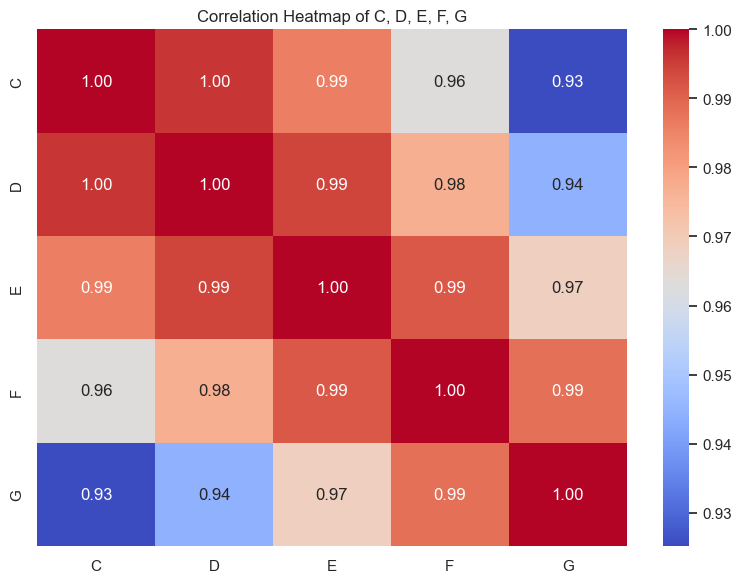

In [7]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(8, 6))
sns.heatmap(df_raw[['C', 'D', 'E', 'F', 'G']].corr(), annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Correlation Heatmap of C, D, E, F, G')
plt.tight_layout()
plt.show()

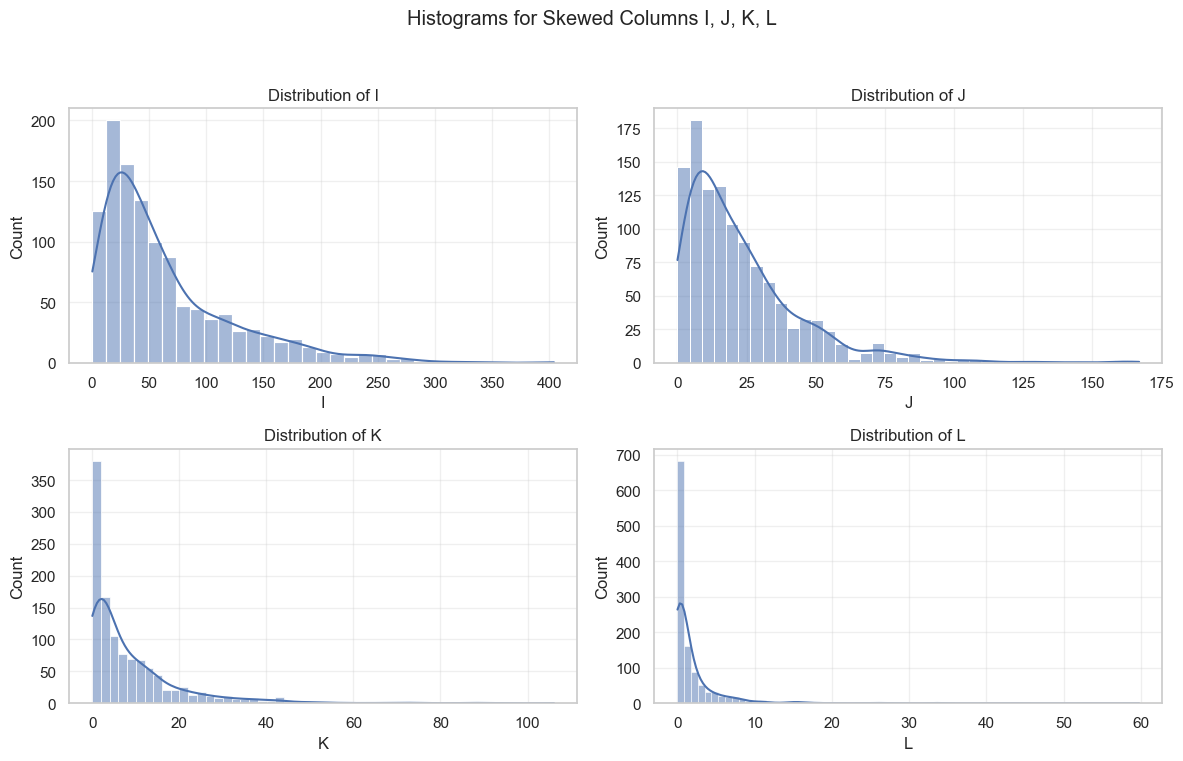

In [8]:
fig, axes = plt.subplots(2, 2, figsize=(12, 8))
fig.suptitle('Histograms for Skewed Columns I, J, K, L')

sns.histplot(df_raw['I'], kde=True, ax=axes[0, 0])
axes[0, 0].set_title('Distribution of I')

sns.histplot(df_raw['J'], kde=True, ax=axes[0, 1])
axes[0, 1].set_title('Distribution of J')

sns.histplot(df_raw['K'], kde=True, ax=axes[1, 0])
axes[1, 0].set_title('Distribution of K')

sns.histplot(df_raw['L'], kde=True, ax=axes[1, 1])
axes[1, 1].set_title('Distribution of L')

plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()

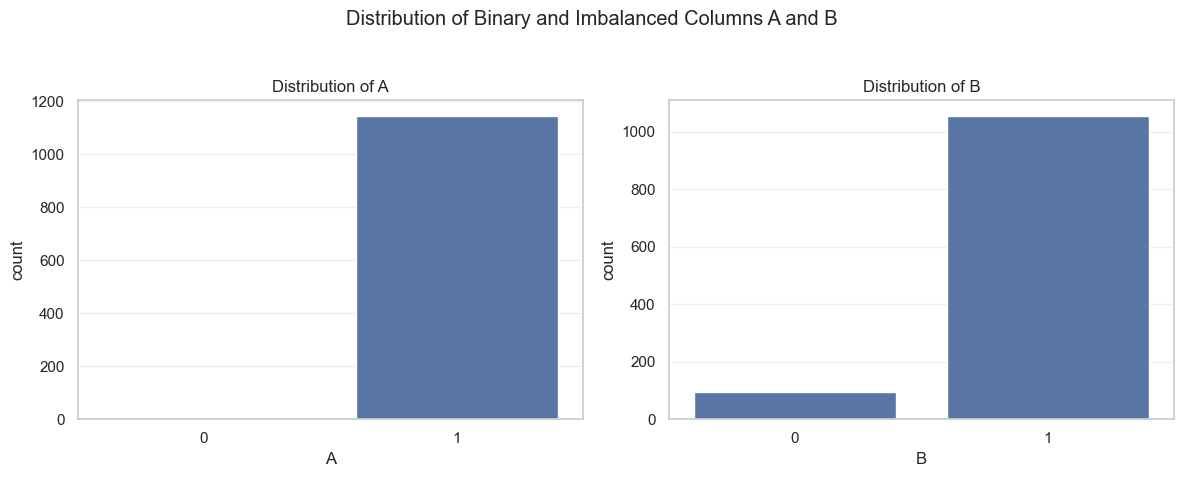

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
fig.suptitle('Distribution of Binary and Imbalanced Columns A and B')

sns.countplot(x='A', data=df_raw, ax=axes[0])
axes[0].set_title('Distribution of A')

sns.countplot(x='B', data=df_raw, ax=axes[1])
axes[1].set_title('Distribution of B')

plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()

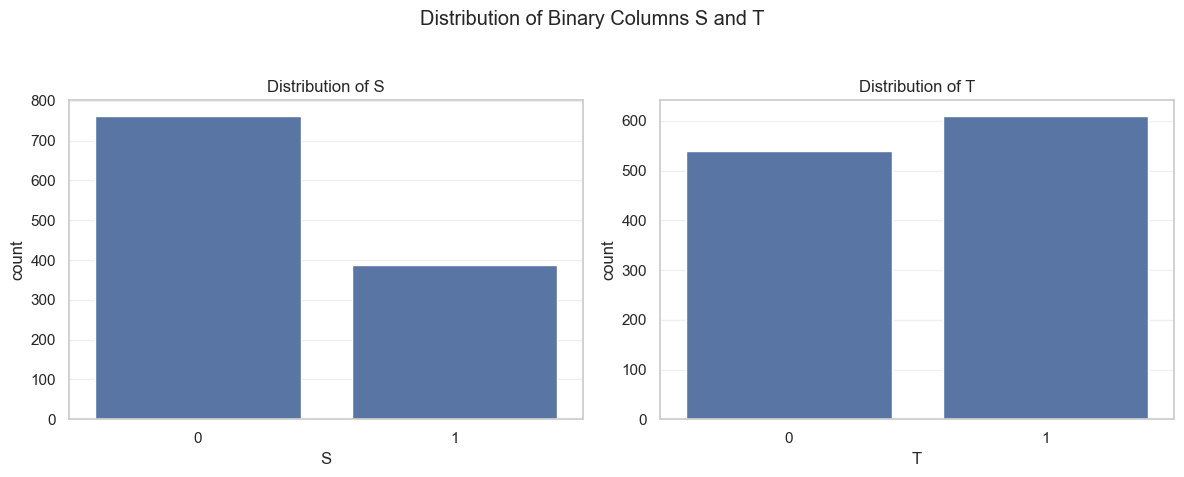

In [10]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
fig.suptitle('Distribution of Binary Columns S and T')

sns.countplot(x='S', data=df_raw, ax=axes[0])
axes[0].set_title('Distribution of S')

sns.countplot(x='T', data=df_raw, ax=axes[1])
axes[1].set_title('Distribution of T')

plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()